# InceptionV3: Training the model
## Loading python modules

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms,datasets
from torchvision.models import Inception_V3_Weights
from PIL import Image
from torch.utils.data import DataLoader
!pip install -q prettypyplot 
import prettypyplot as pplt
import seaborn as sns
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 2.0 MB/s eta 0:00:00


## Loading datasets

In [2]:
transform=transforms.Compose([transforms.Resize((299,299)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='/kaggle/input/spanish-dataset/train_oversampling',transform=transform)
class_names=dataset_train.classes
dataset_val=datasets.ImageFolder(root='/kaggle/input/spanish-dataset/val',transform=transform)
dataset_test=datasets.ImageFolder(root='/kaggle/input/spanish-dataset/test',transform=transform)
print(dataset_test.classes)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## Defining the model and loading the weights

In [3]:
weights = Inception_V3_Weights.DEFAULT
model=models.inception_v3(weights=weights)
for pram in model.parameters():
    pram.requires_grad=True
num_classes=8
model.fc=nn.Linear(model.fc.in_features,num_classes)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 197MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

## Define the preprocess and the loss functions and test them

In [4]:
preprocess = weights.transforms()
criterion=nn.CrossEntropyLoss()
X_batch,y_batch=next(iter(dataloader_train))
y_pred=model(preprocess(X_batch.to(device)))
criterion(y_pred.logits,y_batch.to(device))

tensor(2.0651, device='cuda:0', grad_fn=<NllLossBackward0>)

## Define the optimizer and the Schedular to adopt the learning rate to the training

In [5]:
optimizer=optim.Adam(model.parameters(),lr=0.00001)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,
  mode='min',
  factor=0.1,
  patience=3,
  verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Define an early stop function

In [6]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

## Training the model 

In [ ]:
epochs=100
early_stopper = EarlyStopper(patience=5)
train_loss,train_acc=[],[]
validation_loss,validation_acc=[],[]
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    progress_bar = tqdm(dataloader_train, desc=f'Epoch {epoch+1}/{epochs}', leave=True)

    for i, batch in enumerate(progress_bar):
        X_batch,y_batch=batch
        X_batch=preprocess(X_batch).to(device)
        y_batch=y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)

        if hasattr(outputs, "logits"):  # Inception case
            loss1 = criterion(outputs.logits, y_batch)
            loss2 = criterion(outputs.aux_logits, y_batch) if outputs.aux_logits is not None else 0
            loss = loss1 + 0.4 * loss2
            y_pred = outputs.logits
        else:
            loss = criterion(outputs, y_batch)
            y_pred = outputs

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(y_pred, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

        progress_bar.set_postfix({
            "training_loss": f"{total_loss / (i+1):.3f}",
            "accuracy": f"{100 * correct / total:.2f}%"
        })

    train_loss.append(total_loss / len(dataloader_train))
    train_acc.append(100 * correct / total)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_val, y_val in dataloader_val:
            X_val, y_val = preprocess(X_val).to(device), y_val.to(device)
            outputs = model(X_val)

            if hasattr(outputs, "logits"):
                loss = criterion(outputs.logits, y_val)
                y_pred = outputs.logits
            else:
                loss = criterion(outputs, y_val)
                y_pred = outputs

            val_loss += loss.item()
            _, predicted = torch.max(y_pred, 1)
            val_correct += (predicted == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss /= len(dataloader_val)
    val_accuracy = 100 * val_correct / val_total
    validation_loss.append(val_loss)
    validation_acc.append(val_accuracy)

    scheduler.step(val_loss)  # if ReduceLROnPlateau
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss[-1]:.4f} | "
          f"Train Acc: {train_acc[-1]:.2f}% | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.2f}%")

    if early_stopper.early_stop(val_loss):             
        break


Epoch 1/100:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 1.1884 | Train Acc: 82.66% | Val Loss: 0.1114 | Val Acc: 97.46%


Epoch 2/100:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 2/100 | Train Loss: 0.1620 | Train Acc: 97.04% | Val Loss: 0.0684 | Val Acc: 98.21%


Epoch 3/100:   0%|          | 0/583 [00:00<?, ?it/s]

...

Epoch 8/100 | Train Loss: 0.0171 | Train Acc: 99.68% | Val Loss: 0.0408 | Val Acc: 98.91%


Epoch 9/100:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 9/100 | Train Loss: 0.0124 | Train Acc: 99.79% | Val Loss: 0.0426 | Val Acc: 98.87%


Epoch 10/100:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 10/100 | Train Loss: 0.0074 | Train Acc: 99.87% | Val Loss: 0.0413 | Val Acc: 98.75%


## Plot the loss and the accuracy curves

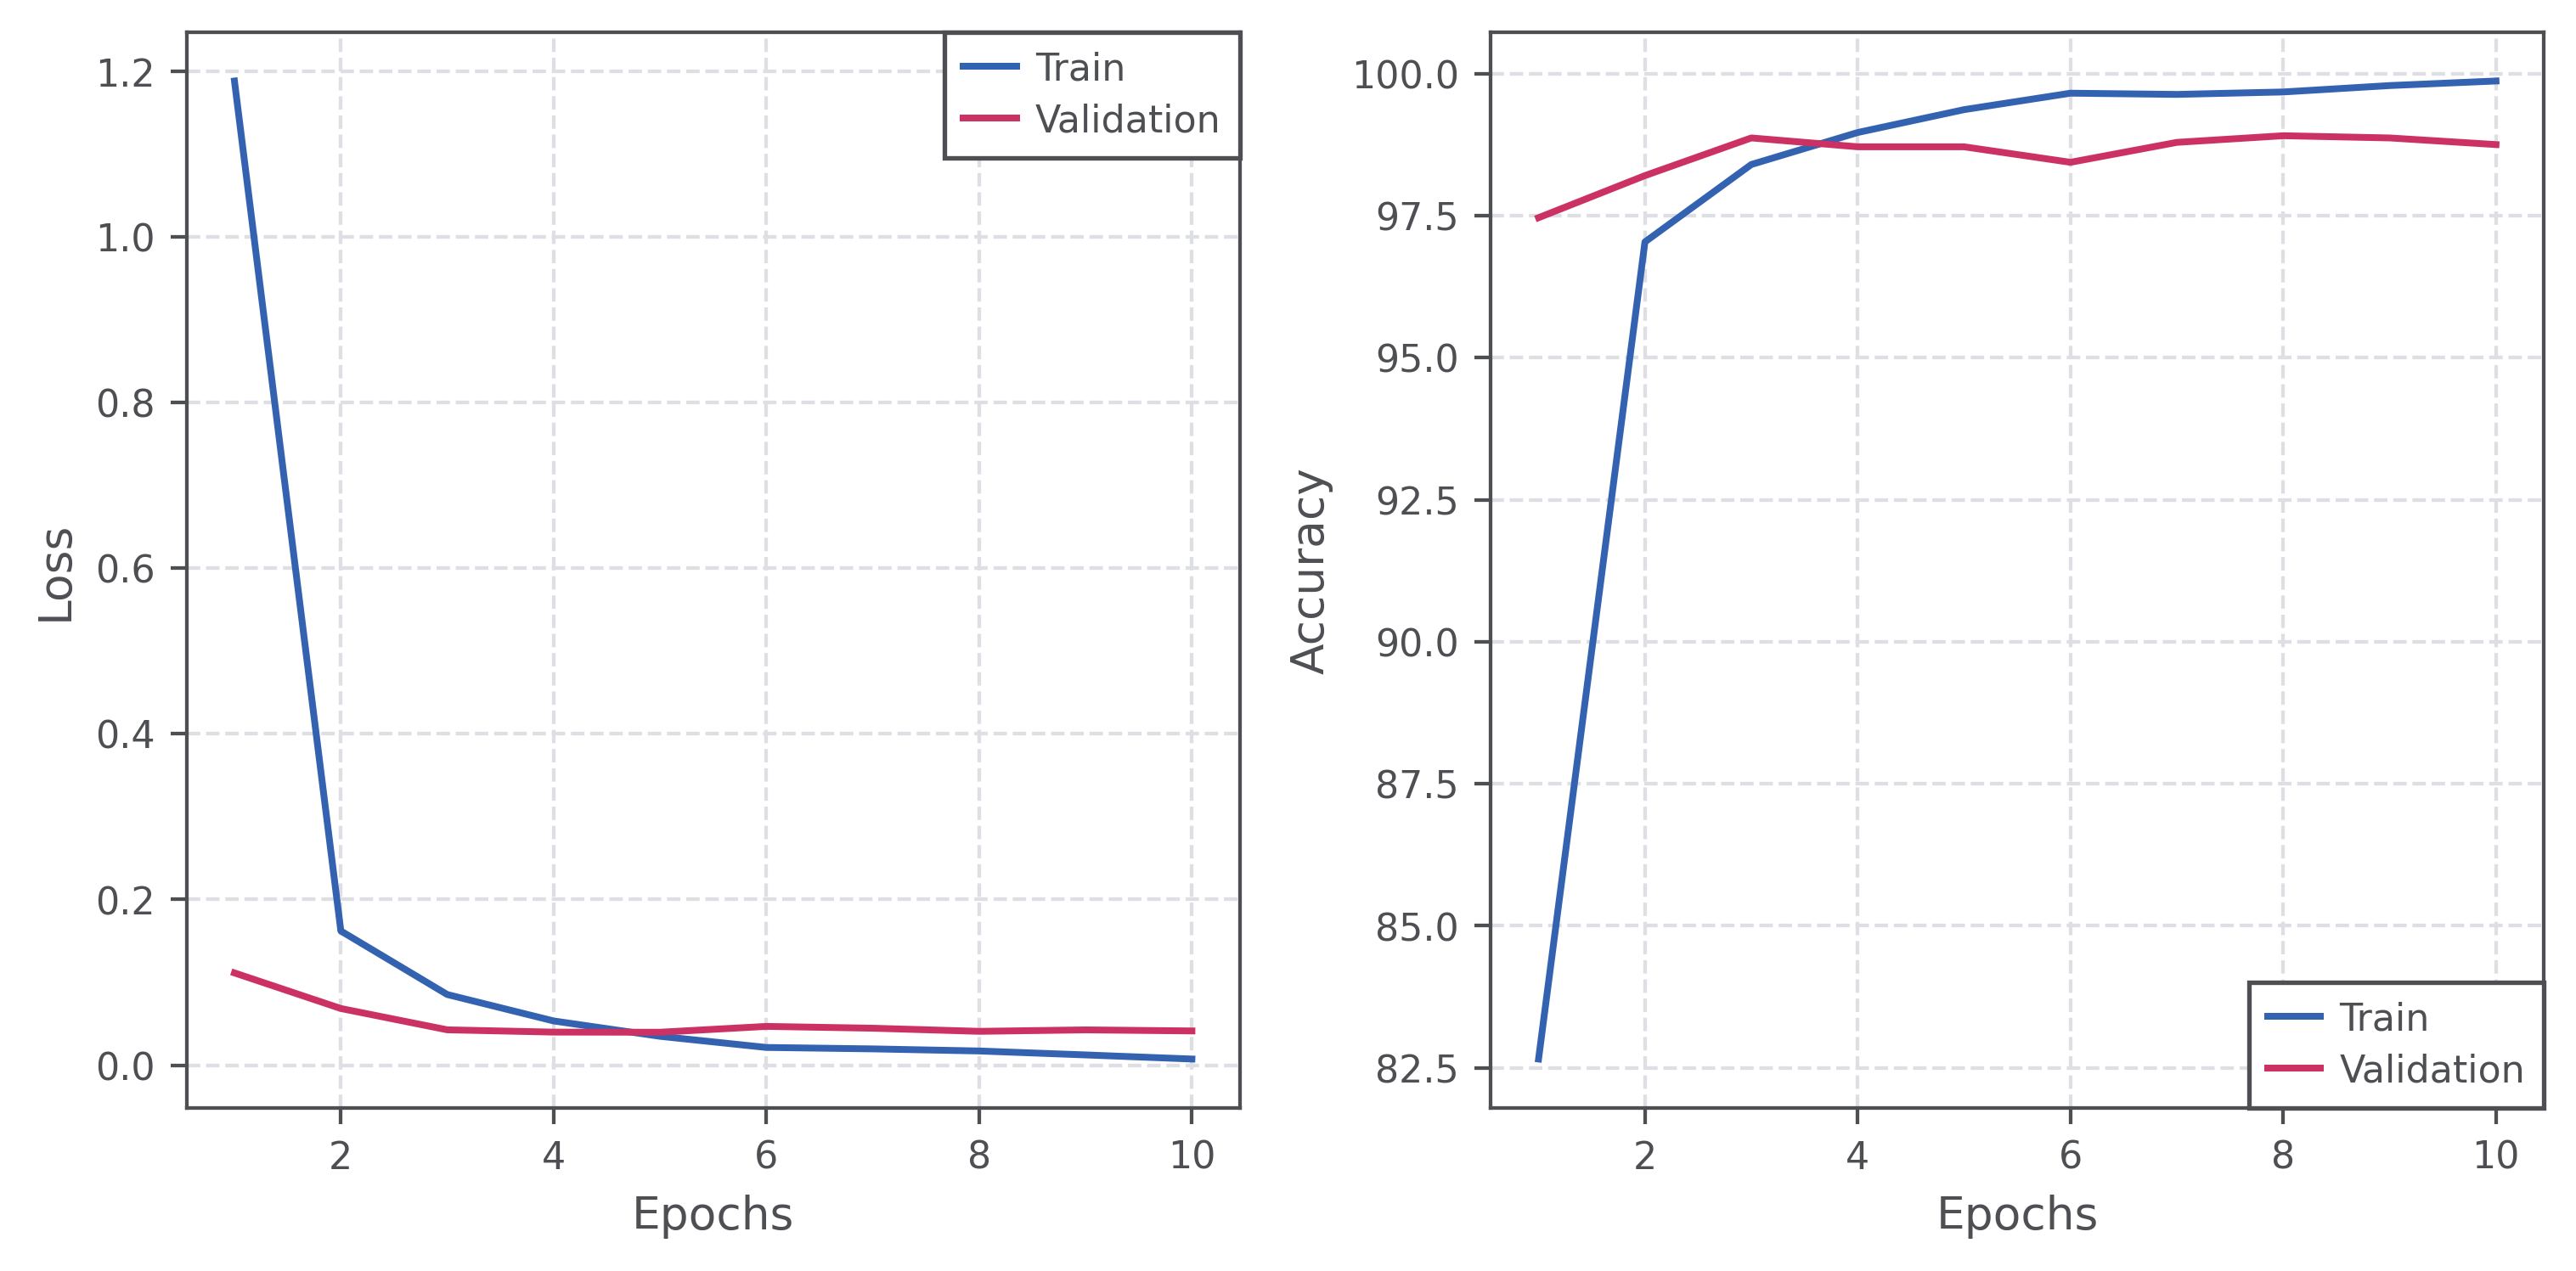

In [8]:
pplt.use_style()
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.plot(np.arange(len(train_loss))+1,train_loss,label='Train')
plt.plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(train_acc))+1,train_acc,label='Train')
plt.plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc.pdf');

## Evaluate the model on the test dataset

In [9]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    loss_val_total = 0
    predictions, true_vals = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = preprocess(X_batch).to(device), y_batch.to(device)

            outputs = model(X_batch.to(torch.float32))

            if hasattr(outputs, "logits"):  # Inception case
                loss = criterion(outputs.logits, y_batch)
                y_pred = outputs.logits
            else:
                loss = criterion(outputs, y_batch)
                y_pred = outputs

            loss_val_total += loss.item()
            predictions.extend(y_pred.detach().cpu().numpy())
            true_vals.extend(y_batch.cpu().numpy())

    loss_val_avg = loss_val_total / len(dataloader)
    predictions = np.argmax(np.array(predictions), axis=-1)
    true_vals = np.array(true_vals)

    acc = accuracy_score(true_vals, predictions)
    return loss_val_avg, acc, true_vals, predictions


# --- Run on test set ---
test_loss, test_acc, y_true, y_pred = evaluate(dataloader_test, model, criterion, device)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Test Loss: 0.0442 | Test Accuracy: 98.68%

              precision    recall  f1-score   support

    basophil       0.99      1.00      1.00       183
  eosinophil       1.00      1.00      1.00       468
erythroblast       0.99      0.99      0.99       233
          ig       0.98      0.97      0.97       435
  lymphocyte       0.97      1.00      0.99       183
    monocyte       0.98      0.97      0.97       214
  neutrophil       0.98      0.98      0.98       500
    platelet       1.00      1.00      1.00       353

    accuracy                           0.99      2569
   macro avg       0.99      0.99      0.99      2569
weighted avg       0.99      0.99      0.99      2569



## Compute and plot the confusion matrix

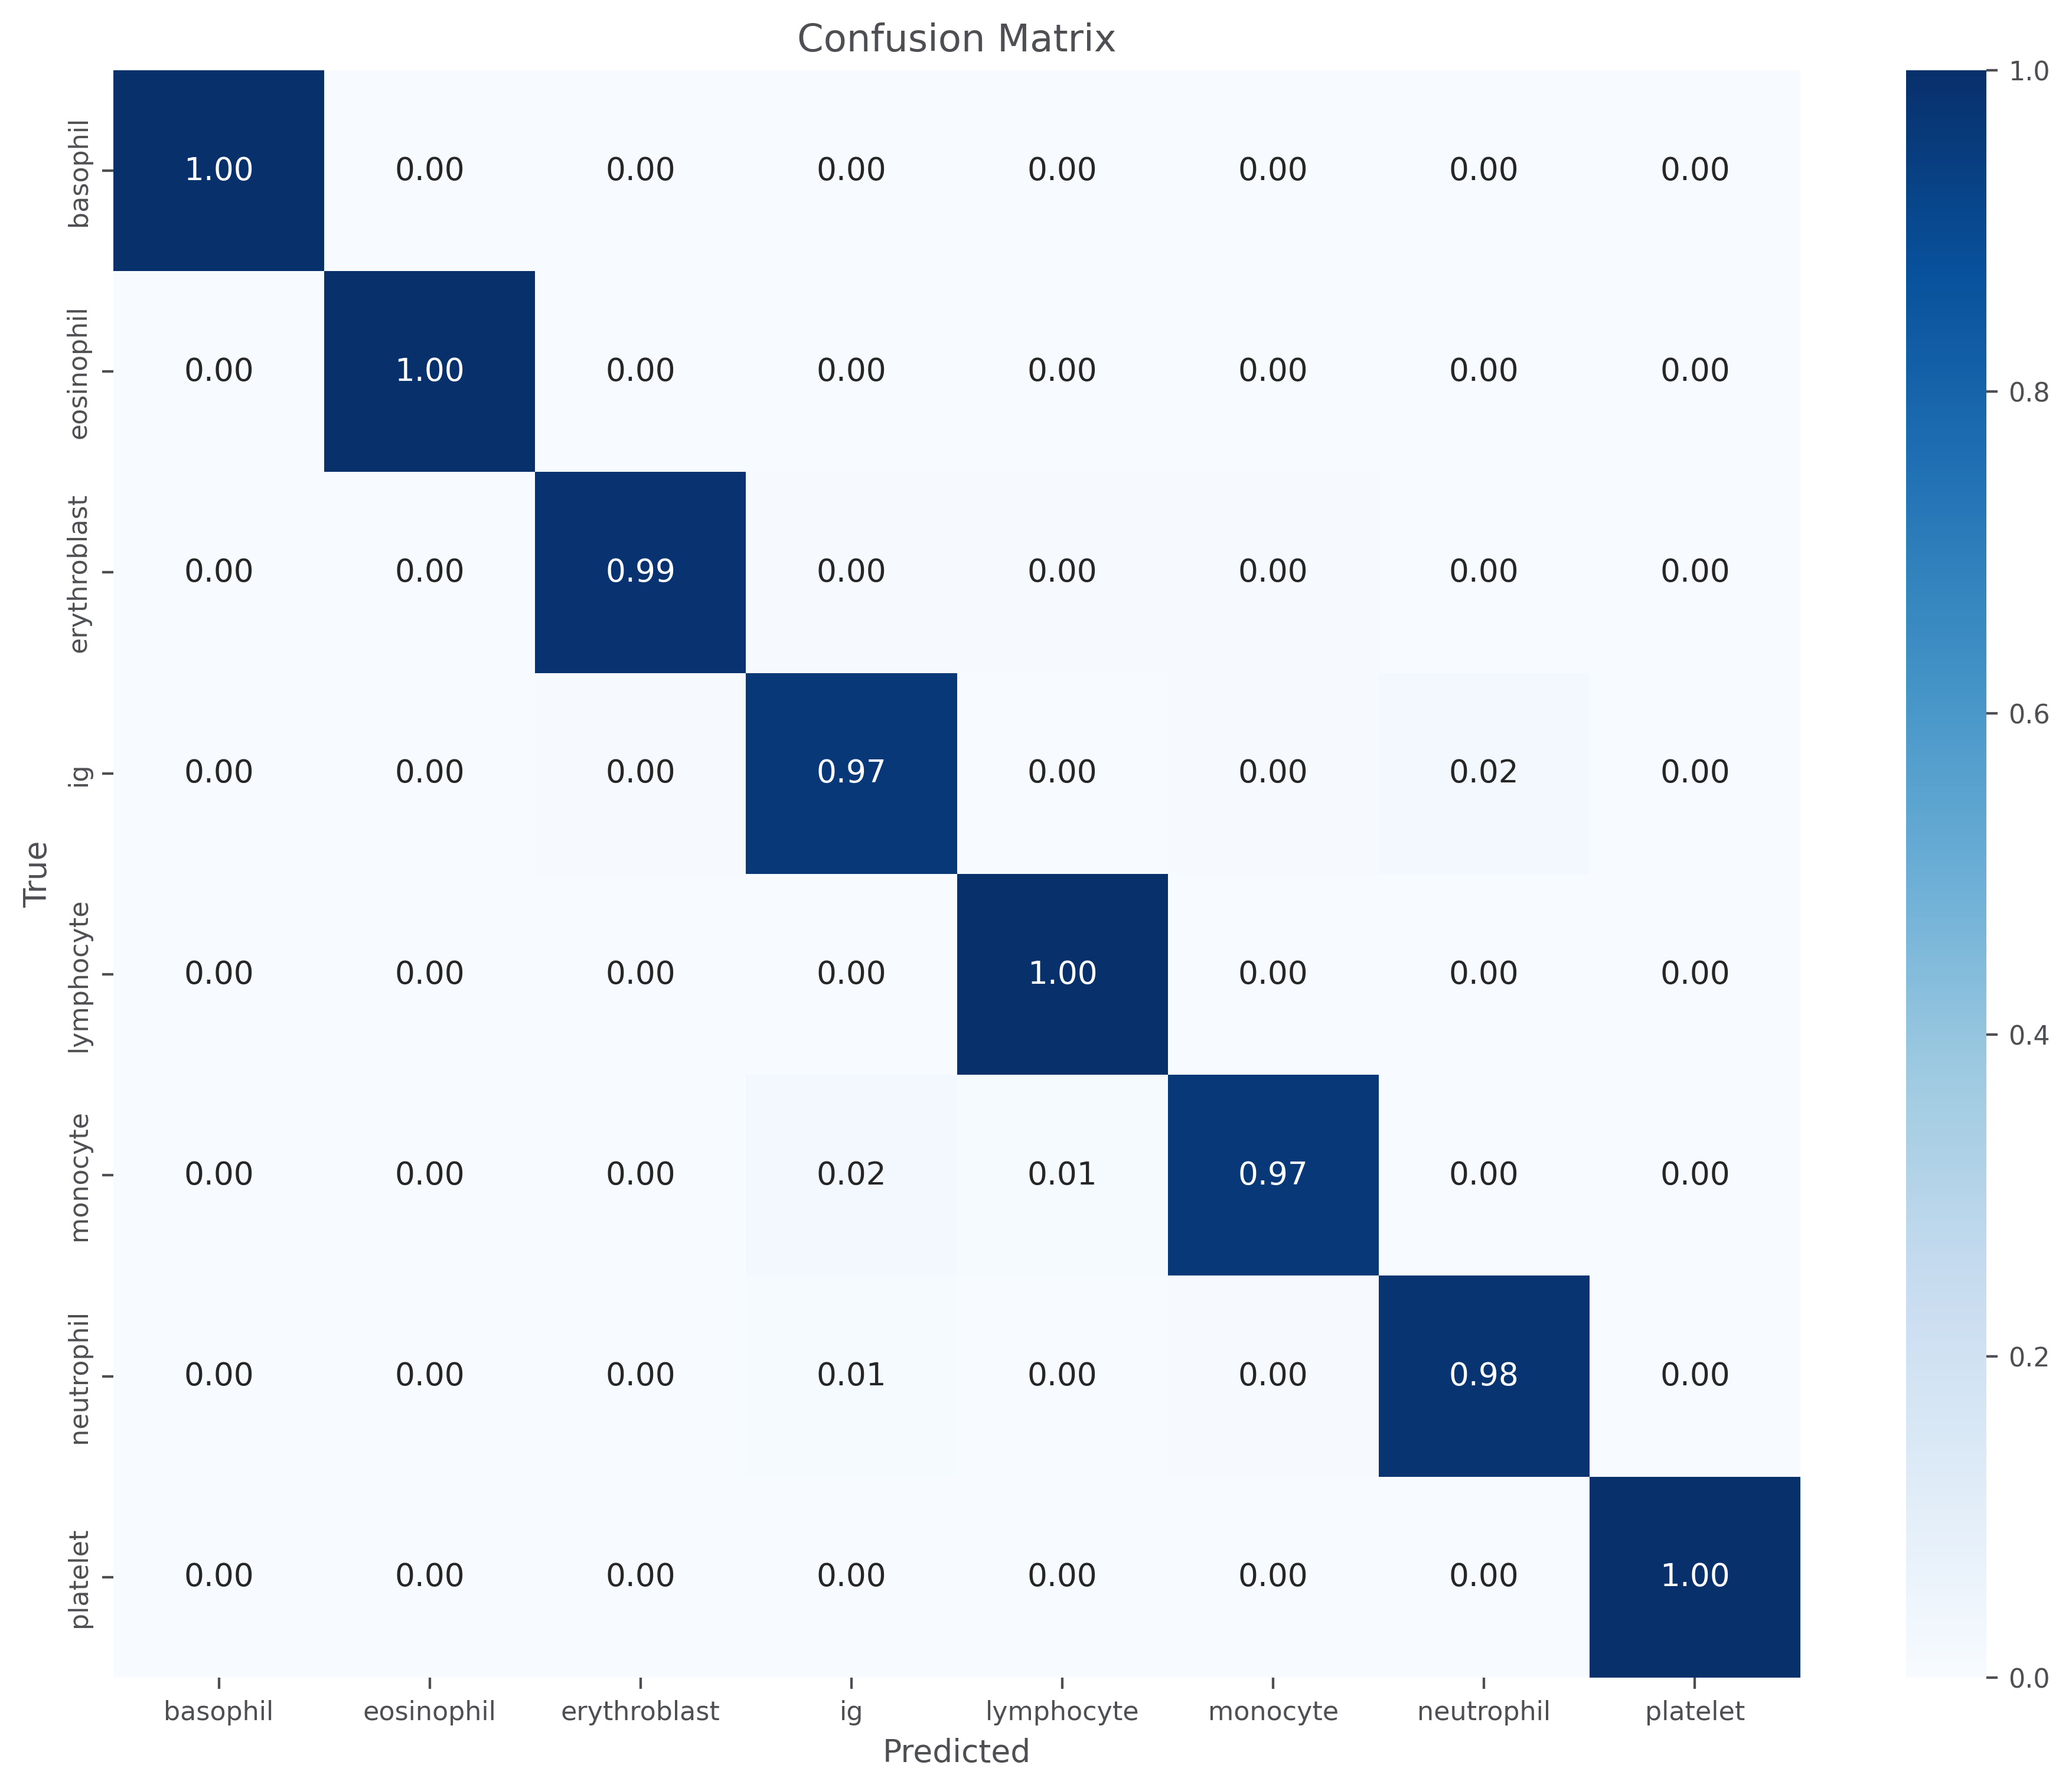

In [10]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm.pdf')
plt.show()

## Save the model and the training history

In [11]:
torch.save(model, 'inceptionv3.pth')
torch.save(model.state_dict(), 'inceptionv3_weights.pth')
with open('history_inceptionv3.txt', 'w') as f:
    for a, b, c, d in zip(train_loss, train_acc, validation_loss, validation_acc):
        f.write(f"{a}\t{b}\t{c}\t{d}\n")